# VAE + Diffusion Map Exploration

This notebook trains a variational autoencoder (VAE) on XY-model lattice configurations and then applies diffusion maps to the learned latent codes to probe emergent structure.


## Workflow

1. Load Ising configurations + metadata generated by `Periodic_Ising_Model.ipynb`, flatten the spin grids, and append thermodynamic observables (temperature + magnetization) to each sample.
2. Train a lightweight PyTorch VAE on the concatenated feature vectors.
3. Encode every configuration, then run diffusion maps on the latent space to capture global structure.
4. Visualize the resulting manifold, coloring by temperature and magnetization to inspect phase-dependent embeddings.

In [1]:
import csv
import pathlib
from typing import Tuple

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

try:
    import torch
    from torch import nn
    from torch.utils.data import Dataset, DataLoader
except ImportError as exc:  # pragma: no cover
    raise ImportError(
        "PyTorch is required for this notebook. Install with `pip install torch`."
    ) from exc

plt.style.use('seaborn-v0_8')
np.set_printoptions(precision=4, suppress=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
RNG = np.random.default_rng(42)


Using device: cuda


In [2]:
data_dir = pathlib.Path('../XYModel').resolve()
config_path = data_dir / 'ising_model_configurations.npy'
metadata_path = data_dir / 'ising_model_metadata.csv'

configs = np.load(config_path).astype(np.float32)
if configs.ndim > 2:
    configs = configs.reshape(configs.shape[0], -1)
print(f"Configurations shape (flattened): {configs.shape}")

rows = []
with metadata_path.open() as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append(row)

if len(rows) != configs.shape[0]:
    raise ValueError("Metadata and configuration counts do not match.")

temperatures = np.array([float(r['temperature']) for r in rows], dtype=np.float32)
magnetization = np.array([float(r['magnetization']) for r in rows], dtype=np.float32)
print(
    f"Loaded {len(rows)} metadata rows. Temp range: {temperatures.min():.3f}–{temperatures.max():.3f}; "
    f"|m| range: {np.abs(magnetization).min():.3f}–{np.abs(magnetization).max():.3f}"
)


Configurations shape (flattened): (200, 4096)
Loaded 200 metadata rows. Temp range: 0.100–3.500; |m| range: 0.001–1.000


In [3]:
spin_features = configs  # already flattened ±1 spins
observables = np.stack([temperatures, magnetization], axis=1)
features = np.concatenate([spin_features, observables], axis=1)
print(f"Spin feature shape: {spin_features.shape}")
print(f"Augmented feature shape (with T + m): {features.shape}")

n_samples = features.shape[0]
train_ratio = 0.8
train_size = int(train_ratio * n_samples)
permutation = RNG.permutation(n_samples)
train_idx = permutation[:train_size]
val_idx = permutation[train_size:]

X_train = features[train_idx]
X_val = features[val_idx]
print(f"Train/val split: {X_train.shape[0]} / {X_val.shape[0]}")

class ArrayDataset(Dataset):
    def __init__(self, array: np.ndarray):
        self.tensor = torch.from_numpy(array)

    def __len__(self) -> int:
        return self.tensor.shape[0]

    def __getitem__(self, idx: int) -> torch.Tensor:
        return self.tensor[idx]

batch_size = 512
train_loader = DataLoader(ArrayDataset(X_train), batch_size=batch_size, shuffle=True, drop_last=False)
val_loader = DataLoader(ArrayDataset(X_val), batch_size=batch_size, shuffle=False, drop_last=False)
full_loader = DataLoader(ArrayDataset(features), batch_size=batch_size, shuffle=False, drop_last=False)


Spin feature shape: (200, 4096)
Augmented feature shape (with T + m): (200, 4098)
Train/val split: 160 / 40


In [4]:
class VAE(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int = 8, hidden_dims: Tuple[int, ...] = (512, 256, 128)):
        super().__init__()
        encoder_layers = []
        last_dim = input_dim
        for h in hidden_dims:
            encoder_layers.append(nn.Linear(last_dim, h))
            encoder_layers.append(nn.ReLU())
            last_dim = h
        self.encoder = nn.Sequential(*encoder_layers)
        self.fc_mu = nn.Linear(last_dim, latent_dim)
        self.fc_logvar = nn.Linear(last_dim, latent_dim)

        decoder_layers = []
        last_dim = latent_dim
        for h in reversed(hidden_dims):
            decoder_layers.append(nn.Linear(last_dim, h))
            decoder_layers.append(nn.ReLU())
            last_dim = h
        decoder_layers.append(nn.Linear(last_dim, input_dim))
        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder(z)

    def forward(self, x: torch.Tensor):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

def vae_loss(recon_x, x, mu, logvar, beta: float = 1.0):
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='mean')
    kld_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kld_loss, recon_loss.detach(), kld_loss.detach()

input_dim = features.shape[1]
latent_dim = 8
vae = VAE(input_dim, latent_dim=latent_dim).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
print(vae)


VAE(
  (encoder): Sequential(
    (0): Linear(in_features=4098, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
  )
  (fc_mu): Linear(in_features=128, out_features=8, bias=True)
  (fc_logvar): Linear(in_features=128, out_features=8, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=4098, bias=True)
  )
)


In [70]:
n_epochs = 500
beta = 1e-3  # balances KLD vs reconstruction
history = {'train_loss': [], 'val_loss': [], 'train_recon': [], 'val_recon': []}

for epoch in range(1, n_epochs + 1):
    vae.train()
    train_losses = []
    train_recon = []
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = vae(batch)
        loss, recon_loss, kld_loss = vae_loss(recon, batch, mu, logvar, beta=beta)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.detach().item())
        train_recon.append(recon_loss.item())

    vae.eval()
    val_losses = []
    val_recon = []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            recon, mu, logvar = vae(batch)
            loss, recon_loss, _ = vae_loss(recon, batch, mu, logvar, beta=beta)
            val_losses.append(loss.item())
            val_recon.append(recon_loss.item())

    history['train_loss'].append(float(np.mean(train_losses)))
    history['val_loss'].append(float(np.mean(val_losses)))
    history['train_recon'].append(float(np.mean(train_recon)))
    history['val_recon'].append(float(np.mean(val_recon)))

    print(f"Epoch {epoch:02d}: train={history['train_loss'][-1]:.4f}, val={history['val_loss'][-1]:.4f}")


Epoch 01: train=0.0044, val=0.6096
Epoch 02: train=0.0043, val=0.6021
Epoch 03: train=0.0045, val=0.5892
Epoch 04: train=0.0043, val=0.5817
Epoch 05: train=0.0044, val=0.5900
Epoch 06: train=0.0044, val=0.5996
Epoch 07: train=0.0044, val=0.6252
Epoch 08: train=0.0043, val=0.5962
Epoch 09: train=0.0043, val=0.5861
Epoch 10: train=0.0043, val=0.6022
Epoch 11: train=0.0044, val=0.6072
Epoch 12: train=0.0044, val=0.6374
Epoch 13: train=0.0045, val=0.6293
Epoch 14: train=0.0045, val=0.6093
Epoch 15: train=0.0044, val=0.5878
Epoch 16: train=0.0045, val=0.6247
Epoch 17: train=0.0044, val=0.6244
Epoch 18: train=0.0044, val=0.6449
Epoch 19: train=0.0042, val=0.6064
Epoch 20: train=0.0043, val=0.6149
Epoch 21: train=0.0043, val=0.6340


Epoch 22: train=0.0044, val=0.6201
Epoch 23: train=0.0044, val=0.6096
Epoch 24: train=0.0043, val=0.6330
Epoch 25: train=0.0044, val=0.5975
Epoch 26: train=0.0043, val=0.6013
Epoch 27: train=0.0043, val=0.6262
Epoch 28: train=0.0044, val=0.6018
Epoch 29: train=0.0043, val=0.5906
Epoch 30: train=0.0043, val=0.6118
Epoch 31: train=0.0043, val=0.6151
Epoch 32: train=0.0043, val=0.6366
Epoch 33: train=0.0043, val=0.6175
Epoch 34: train=0.0043, val=0.6205
Epoch 35: train=0.0043, val=0.6094
Epoch 36: train=0.0043, val=0.6138
Epoch 37: train=0.0043, val=0.6045
Epoch 38: train=0.0043, val=0.6205
Epoch 39: train=0.0042, val=0.5847
Epoch 40: train=0.0043, val=0.6002
Epoch 41: train=0.0043, val=0.6150
Epoch 42: train=0.0042, val=0.5989
Epoch 43: train=0.0043, val=0.6134
Epoch 44: train=0.0043, val=0.5967
Epoch 45: train=0.0043, val=0.6142
Epoch 46: train=0.0043, val=0.6232
Epoch 47: train=0.0043, val=0.6167
Epoch 48: train=0.0043, val=0.5834
Epoch 49: train=0.0044, val=0.6072
Epoch 50: train=0.00

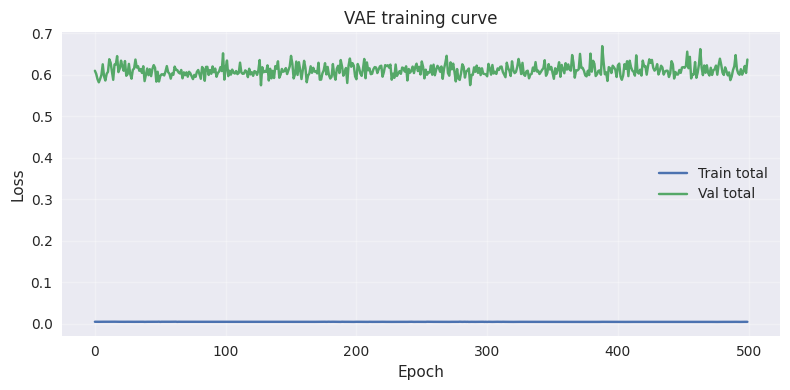

In [71]:
plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='Train total')
plt.plot(history['val_loss'], label='Val total')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE training curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [72]:
vae.eval()
latents = []
with torch.no_grad():
    for batch in full_loader:
        batch = batch.to(device)
        mu, _ = vae.encode(batch)
        latents.append(mu.cpu().numpy())

latents = np.concatenate(latents, axis=0)
print(f"Latent matrix shape: {latents.shape}")


Latent matrix shape: (200, 8)


In [73]:
def pairwise_sq_dists(X: np.ndarray) -> np.ndarray:
    norms = np.sum(X ** 2, axis=1, keepdims=True)
    dists = norms + norms.T - 2 * X @ X.T
    np.maximum(dists, 0.0, out=dists)
    return dists

def diffusion_map_embedding(X: np.ndarray, epsilon: float | None = None, n_dims: int = 3, diffusion_time: int = 1):
    n_samples = X.shape[0]
    dists = pairwise_sq_dists(X)
    if epsilon is None:
        triu = dists[np.triu_indices(n_samples, k=1)]
        epsilon = np.median(triu)
    epsilon = max(epsilon, 1e-8)
    K = np.exp(-dists / epsilon)
    row_sums = K.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    P = K / row_sums
    evals, evecs = np.linalg.eig(P.T)
    idx = np.argsort(-np.abs(evals))
    evals = np.real_if_close(evals[idx])
    evecs = np.real_if_close(evecs[:, idx])
    start = 1
    end = start + n_dims
    coords = evecs[:, start:end] * (evals[start:end] ** diffusion_time)
    return evals, coords


In [86]:
max_samples = 25000
n_total = latents.shape[0]
if n_total > max_samples:
    subset_idx = RNG.choice(n_total, size=max_samples, replace=False)
else:
    subset_idx = np.arange(n_total)

latent_subset = latents[subset_idx]
temp_subset = temperatures[subset_idx]
mag_subset = magnetization[subset_idx]

print(f"Running diffusion maps on {latent_subset.shape[0]} latent vectors...")

evals, dm_coords = diffusion_map_embedding(
    latent_subset,
    epsilon=None,
    n_dims=3,
    diffusion_time=1,
)
print("Leading diffusion eigenvalues:", evals[:5])


Running diffusion maps on 200 latent vectors...
Leading diffusion eigenvalues: [1.     0.2059 0.1451 0.1345 0.1219]


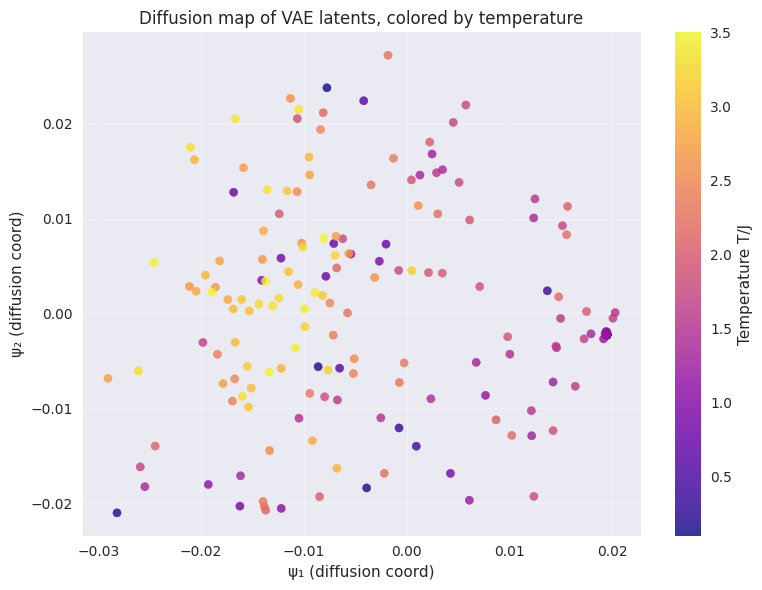

In [87]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(dm_coords[:, 0], dm_coords[:, 1], c=temp_subset, cmap='plasma', s=35, alpha=0.8)
plt.xlabel('ψ₁ (diffusion coord)')
plt.ylabel('ψ₂ (diffusion coord)')
plt.title('Diffusion map of VAE latents, colored by temperature')
plt.grid(True, alpha=0.3)
cbar = plt.colorbar(sc)
cbar.set_label('Temperature T/J')
plt.tight_layout()
plt.show()


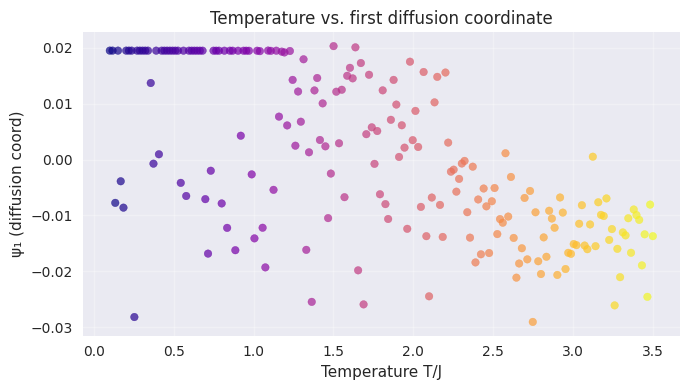

In [88]:
plt.figure(figsize=(7, 4))
plt.scatter(temp_subset, dm_coords[:, 0], c=temp_subset, cmap='plasma', s=30, alpha=0.7)
plt.xlabel('Temperature T/J')
plt.ylabel('ψ₁ (diffusion coord)')
plt.title('Temperature vs. first diffusion coordinate')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


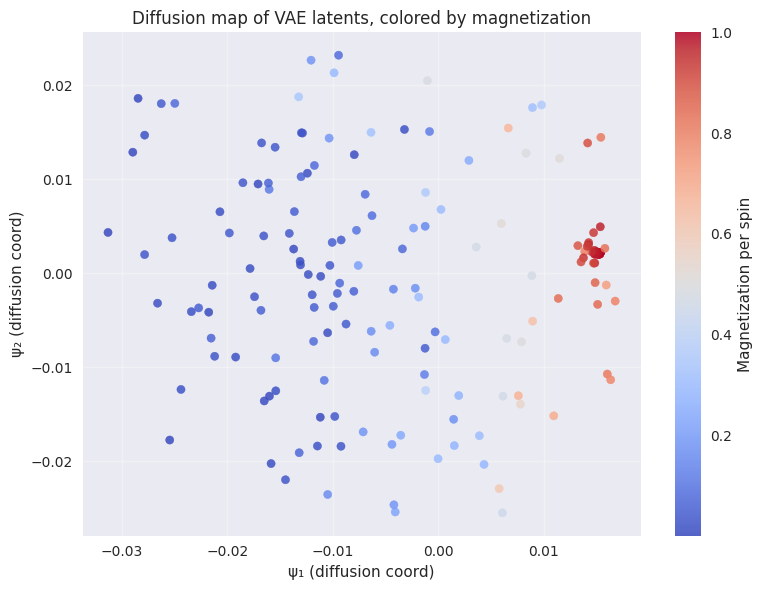

In [28]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(dm_coords[:, 0], dm_coords[:, 1], c=mag_subset, cmap='coolwarm', s=35, alpha=0.85)
plt.xlabel('ψ₁ (diffusion coord)')
plt.ylabel('ψ₂ (diffusion coord)')
plt.title('Diffusion map of VAE latents, colored by magnetization')
plt.grid(True, alpha=0.3)
cbar = plt.colorbar(sc)
cbar.set_label('Magnetization per spin')
plt.tight_layout()
plt.show()
